In [1]:
#Load packages
import warnings
warnings.filterwarnings("ignore")
from watermark import watermark

#file operating
import json
import os
import os.path
import re
import cv2
import sys

#data processing platform
import anndata as ad
import geopandas as gpd
import numpy as np
import pandas as pd
import spatialdata as sd
import squidpy as sq
import scanpy as sc
import spatialdata_plot
from shapely.geometry import Polygon
from spatialdata import bounding_box_query
from spatialdata.models import ShapesModel, Labels2DModel
from spatialdata.models import Image2DModel 
from spatialdata.transformations import Scale
from spatialdata.transformations import get_transformation, set_transformation, Affine, Identity, Sequence
from spatialdata_io import visium_hd
pd.set_option("io.parquet.engine", "fastparquet")

#plotting
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

In [2]:
%load_ext watermark

In [3]:
#folder/ file setup based on your project
sourcefiles = "/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/source_files"
zarrfiles = "/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/zarr_files"
outputfiles = "/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/derived_files/"
functiondirs = "/host_root/nethome/reny28/Projects/Custom_functions/python_functions"

In [4]:
#load custom function
sys.path.append(functiondirs)
## to remove given string from a list of strings 
from cfs_spatialdata_202412 import (remove_char, replace_table, persist_changes
, make_global_fullres, verify_global_extents
, read_imagescope_annotation_xml)

from cfs_normhe_202605 import (macenko_normalize_visiumhd, robust_rescale_to_uint8
, extract_he_from_imagecontainer, preview_he_concentration_maps)

In [5]:
# test functions
## combine h&e for tissue signal
import numpy as np


def combine_he_tissue_signal(
    H_u8,
    E_u8,
    *,
    method="soft_union",
    h_weight=0.6,
    e_weight=1.0,
    h_threshold=None,
    e_threshold=None,
):
    """
    Combine uint8 H/E concentration maps into an overall tissue signal.

    Parameters
    ----------
    H_u8, E_u8
        Hematoxylin and Eosin concentration maps scaled to 0–255.
    method
        "soft_union", "max", or "weighted_mean".
    h_weight, e_weight
        Relative contributions. A lower H weight is reasonable when
        hematoxylin separation is noisy.
    h_threshold, e_threshold
        Optional thresholds on the 0–1 scale for generating a binary
        tissue mask.

    Returns
    -------
    score
        Continuous tissue score in [0, 1].
    tissue_mask
        Boolean mask, or None when thresholds are not supplied.
    """
    H = np.clip(np.asarray(H_u8, dtype=np.float32) / 255.0, 0, 1)
    E = np.clip(np.asarray(E_u8, dtype=np.float32) / 255.0, 0, 1)

    Hw = np.clip(h_weight * H, 0, 1)
    Ew = np.clip(e_weight * E, 0, 1)

    if method == "soft_union":
        score = 1.0 - (1.0 - Hw) * (1.0 - Ew)
    elif method == "max":
        score = np.maximum(Hw, Ew)
    elif method == "weighted_mean":
        denom = h_weight + e_weight
        if denom <= 0:
            raise ValueError("At least one stain weight must be positive.")
        score = (h_weight * H + e_weight * E) / denom
    else:
        raise ValueError("method must be 'soft_union', 'max', or 'weighted_mean'.")

    tissue_mask = None
    if h_threshold is not None and e_threshold is not None:
        # A pixel is tissue when either nuclear or cytoplasmic stain is present.
        tissue_mask = (H >= h_threshold) | (E >= e_threshold)

    return score.astype(np.float32), tissue_mask

In [6]:
# Directly map the image score to all 2 µm bins
from scipy.ndimage import map_coordinates
from tqdm.auto import tqdm


def map_hires_image_to_visiumhd_bins(
    adata,
    image_2d,
    *,
    tissue_hires_scalef,
    out_key,
    spatial_key="spatial",
    interpolation="linear",
    chunk_size=1_000_000,
    show_progress=True,
):
    """
    Sample a hires-resolution 2D image at Visium HD bin centers.

    Assumes:
      adata.obsm[spatial_key][:, 0] = x in full-resolution pixels
      adata.obsm[spatial_key][:, 1] = y in full-resolution pixels

    Writes:
      adata.obs[out_key]
      adata.obs[f"{out_key}_in_bounds"]
    """
    field = np.asarray(image_2d, dtype=np.float32)

    if field.ndim != 2:
        raise ValueError(f"image_2d must be 2D; received shape {field.shape}.")

    H, W = field.shape
    xy = np.asarray(adata.obsm[spatial_key])

    if xy.ndim != 2 or xy.shape[1] < 2:
        raise ValueError(
            f"adata.obsm[{spatial_key!r}] must be an N×2 coordinate matrix."
        )

    n = adata.n_obs
    values = np.full(n, np.nan, dtype=np.float32)
    in_bounds = np.zeros(n, dtype=bool)

    order = {"nearest": 0, "linear": 1}.get(interpolation)
    if order is None:
        raise ValueError("interpolation must be 'nearest' or 'linear'.")

    starts = range(0, n, chunk_size)
    if show_progress:
        starts = tqdm(
            starts,
            total=(n + chunk_size - 1) // chunk_size,
            desc=f"Mapping {out_key}",
            unit="chunk",
        )

    for start in starts:
        end = min(start + chunk_size, n)

        # Full-resolution positions -> hires-image positions.
        x = xy[start:end, 0].astype(np.float64) * tissue_hires_scalef
        y = xy[start:end, 1].astype(np.float64) * tissue_hires_scalef

        valid = (
            np.isfinite(x)
            & np.isfinite(y)
            & (x >= 0)
            & (x <= W - 1)
            & (y >= 0)
            & (y <= H - 1)
        )

        in_bounds[start:end] = valid

        if valid.any():
            vals = map_coordinates(
                field,
                coordinates=np.vstack([y[valid], x[valid]]),
                order=order,
                mode="constant",
                cval=np.nan,
                prefilter=False,
            )
            local_idx = np.flatnonzero(valid) + start
            values[local_idx] = vals.astype(np.float32, copy=False)

    adata.obs[out_key] = values
    adata.obs[f"{out_key}_in_bounds"] = in_bounds

    adata.uns[f"{out_key}_mapping"] = {
        "source": "hires image",
        "tissue_hires_scalef": float(tissue_hires_scalef),
        "interpolation": interpolation,
        "n_in_bounds": int(in_bounds.sum()),
        "n_out_of_bounds": int((~in_bounds).sum()),
    }

    return values

In [7]:
import numpy as np
import gc
#

def _as_hwc(img_cyx: np.ndarray) -> np.ndarray:
    if img_cyx.ndim != 3 or img_cyx.shape[0] not in (3, 4):
        raise ValueError(
            f"Expected image with shape (c, y, x) and 3 or 4 channels. Got {img_cyx.shape}."
        )
    return np.moveaxis(img_cyx[:3], 0, -1)


def _batch_lstsq(HE: np.ndarray, Y: np.ndarray, batch: int = 200_000) -> np.ndarray:
    Cs = []
    for i in range(0, Y.shape[1], batch):
        C_i, _, _, _ = np.linalg.lstsq(HE, Y[:, i:i + batch], rcond=None)
        Cs.append(C_i)
    return np.concatenate(Cs, axis=1)


def estimate_background_Io_rgb(
    img_hwc,
    *,
    sat_max=0.08,
    value_quantile=90,
    io_quantile=99.5,
    fallback=255.0,
):
    """
    Optional white-background estimator.
    This can reduce blue-background artifacts, but it is sample-specific.

    Returns
    -------
    Io_rgb : np.ndarray, shape (3,)
    """
    from matplotlib.colors import rgb_to_hsv

    I = np.asarray(img_hwc, dtype=np.float32)
    I01 = np.clip(I / 255.0, 0, 1)

    hsv = rgb_to_hsv(I01)
    sat = hsv[..., 1]
    val = hsv[..., 2]

    v_thr = np.percentile(val, value_quantile)
    bg = (val >= v_thr) & (sat <= sat_max)

    if bg.sum() < 1000:
        return np.array([fallback, fallback, fallback], dtype=np.float32)

    Io_rgb = np.percentile(I[bg, :3], io_quantile, axis=0)
    Io_rgb = np.where(np.isfinite(Io_rgb) & (Io_rgb > 10), Io_rgb, fallback)

    return Io_rgb.astype(np.float32)


def extract_he_concentrations_reference(
    img,
    *,
    Io=255.0,                    # fixed hard-code default
    white_balance=False,          # set True if blue background is very visible
    clip_concentrations=True,
    lstsq_batch=200_000,
):
    """
    Extract H/E concentration maps using fixed reference H&E vectors.

    This is intended for tissue-amount scoring, not necessarily for RGB display.

    Returns
    -------
    H_conc : np.ndarray, shape (y, x), float32
    E_conc : np.ndarray, shape (y, x), float32
    Io_used : float or np.ndarray
    """

    HERef = np.array(
        [[0.5626, 0.2159],
         [0.7201, 0.8012],
         [0.4062, 0.5581]],
        dtype=np.float64,
    )

    # Accept xarray / SpatialData image or numpy
    try:
        import xarray as xr
        if isinstance(img, xr.DataArray):
            arr = img.values
        else:
            arr = img
    except Exception:
        arr = img

    if arr.shape[0] in (3, 4):
        I = _as_hwc(arr)
    elif arr.shape[-1] in (3, 4):
        I = arr[..., :3]
    else:
        raise ValueError("Provide RGB image as (c,y,x) or (y,x,c).")

    h, w, _ = I.shape
    I = I.astype(np.float32, copy=False)

    if white_balance:
        Io_used = estimate_background_Io_rgb(I)
    else:
        Io_used = float(Io)

    # allow scalar or RGB-vector Io
    Io_arr = np.asarray(Io_used, dtype=np.float32)
    if Io_arr.ndim == 0:
        Io_arr = np.array([float(Io_arr)] * 3, dtype=np.float32)

    # avoid negative OD from pixels brighter than estimated Io
    I_clip = np.minimum(I, Io_arr.reshape(1, 1, 3) - 1.0)
    I_clip = np.maximum(I_clip, 0)

    OD = -np.log((I_clip + 1.0) / Io_arr.reshape(1, 1, 3))
    OD = OD.astype(np.float32, copy=False)

    Y = OD.reshape(-1, 3).T

    gc.collect()
    C = _batch_lstsq(HERef, Y, batch=lstsq_batch).astype(np.float32, copy=False)
    gc.collect()

    if clip_concentrations:
        C[C < 0] = 0

    H_conc = C[0, :].reshape(h, w).astype(np.float32, copy=False)
    E_conc = C[1, :].reshape(h, w).astype(np.float32, copy=False)

    return H_conc, E_conc, Io_used


#
def fixed_scale_he_tissue_score(
    H_conc,
    E_conc,
    *,
    h_limit=1.9705,
    e_limit=1.0308,
    h_weight=1.0,
    e_weight=1.0,
    method="soft_union",
):
    """
    Convert raw H/E concentration maps into a fixed 0-1 tissue score.

    H and E are first divided by hard-coded limits, not by per-sample quantiles.
    """

    H = np.asarray(H_conc, dtype=np.float32)
    E = np.asarray(E_conc, dtype=np.float32)

    Hn = np.clip(H / float(h_limit), 0, 1)
    En = np.clip(E / float(e_limit), 0, 1)

    Hw = np.clip(h_weight * Hn, 0, 1)
    Ew = np.clip(e_weight * En, 0, 1)

    if method == "soft_union":
        # high if either H or E is high, but bounded and no double-counting
        score = 1.0 - (1.0 - Hw) * (1.0 - Ew)
    elif method == "max":
        score = np.maximum(Hw, Ew)
    elif method == "weighted_mean":
        score = (h_weight * Hn + e_weight * En) / (h_weight + e_weight)
    else:
        raise ValueError("method must be 'soft_union', 'max', or 'weighted_mean'.")

    return score.astype(np.float32), Hn.astype(np.float32), En.astype(np.float32)

#

def combine_he_fixed_tissue_signal(
    H_fixed,
    E_fixed,
    *,
    method="soft_union",
    h_weight=1.0,
    e_weight=1.0,
    score_threshold=None,
    h_threshold=None,
    e_threshold=None,
):
    """
    Combine fixed-scale H and E concentration maps into one tissue score.

    Parameters
    ----------
    H_fixed, E_fixed
        Fixed-scale concentration maps, expected in [0, 1].
        These should NOT be robust-rescaled per sample.

    method
        "soft_union": 1 - (1-H)(1-E), bounded and no double-counting.
        "max": maximum of H and E evidence.
        "weighted_mean": weighted average of H and E.

    h_weight, e_weight
        Relative stain weights. If H is noisy, reduce h_weight.

    score_threshold
        Optional threshold on combined score.

    h_threshold, e_threshold
        Optional stain-specific thresholds. If provided, tissue_mask is:
        (H >= h_threshold) OR (E >= e_threshold).

    Returns
    -------
    score : np.ndarray
        Combined fixed-scale tissue score in [0, 1].

    tissue_mask : np.ndarray or None
        Boolean mask if thresholds are provided; otherwise None.
    """
    H = np.clip(np.asarray(H_fixed, dtype=np.float32), 0, 1)
    E = np.clip(np.asarray(E_fixed, dtype=np.float32), 0, 1)

    Hw = np.clip(h_weight * H, 0, 1)
    Ew = np.clip(e_weight * E, 0, 1)

    if method == "soft_union":
        score = 1.0 - (1.0 - Hw) * (1.0 - Ew)
    elif method == "max":
        score = np.maximum(Hw, Ew)
    elif method == "weighted_mean":
        denom = h_weight + e_weight
        if denom <= 0:
            raise ValueError("h_weight + e_weight must be > 0.")
        score = (h_weight * H + e_weight * E) / denom
    else:
        raise ValueError("method must be 'soft_union', 'max', or 'weighted_mean'.")

    score = np.clip(score, 0, 1).astype(np.float32)

    tissue_mask = None

    if score_threshold is not None:
        tissue_mask = score >= float(score_threshold)

    if h_threshold is not None and e_threshold is not None:
        tissue_mask = (H >= float(h_threshold)) | (E >= float(e_threshold))

    return score, tissue_mask

In [8]:
#get sample names
visiumhd_ls = [entry for entry in os.listdir(sourcefiles)]
sample_names = remove_char(visiumhd_ls, "")#no common prefix for this dataset
print(sample_names)

['Ada-7', 'Ada-6', 'Ada-16', 'Ada-12', 'Ada-14R', 'Ada-15', 'Ada-1', 'Ada-11R', 'Ada-9', 'Ada-3R', 'Ada-4R', 'Ada-8']


In [9]:
#load all pilot samples to a list to be saved as zarr files later
visiumhd_files = [os.path.join(zarrfiles
                               , visiumhd_file + '.zarr') for visiumhd_file in visiumhd_ls]
visiumhd_files = dict(zip(sample_names, visiumhd_files)) 
print(visiumhd_files)

{'Ada-7': '/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/zarr_files/Ada-7.zarr', 'Ada-6': '/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/zarr_files/Ada-6.zarr', 'Ada-16': '/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/zarr_files/Ada-16.zarr', 'Ada-12': '/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/zarr_files/Ada-12.zarr', 'Ada-14R': '/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/zarr_files/Ada-14R.zarr', 'Ada-15': '/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/zarr_files/Ada-15.zarr', 'Ada-1': '/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/zarr_files/Ada-1.zarr', 'Ada-11R': '/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/zarr_files/Ada-11R.zarr', 'Ada-9': '/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/zarr_files/Ada-9.zarr', 'Ada-3R': '/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/zarr_files/Ada-3R.zarr', 'Ada-4R': '/stash/data/nonclin/TBIO-8110_Vi

In [10]:
#load 2um bins for finest resolution
s_names = ["sample_" + sample_name for sample_name in sample_names]
visiumhd_ls = [sd.SpatialData.read(visiumhd_file) for key, visiumhd_file in visiumhd_files.items()]

print(len(visiumhd_ls))
#organzie data into dictionary and preview
visiumhd_ls = dict(zip(s_names, visiumhd_ls)) 
print(visiumhd_ls)

12
{'sample_Ada-7': SpatialData object, with associated Zarr store: /stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/zarr_files/Ada-7.zarr
├── Images
│     ├── 'Ada-7_hires_image': DataArray[cyx] (3, 3399, 6000)
│     ├── 'Ada-7_lowres_image': DataArray[cyx] (3, 340, 600)
│     └── 'Ada-7_nhires_image': DataArray[cyx] (3, 3399, 6000)
├── Shapes
│     └── 'Ada-7_square_002um': GeoDataFrame shape: (11222500, 1) (2D shapes)
└── Tables
      └── 'square_002um': AnnData (11222500, 32285)
with coordinate systems:
    ▸ 'Ada-7', with elements:
        Ada-7_hires_image (Images), Ada-7_lowres_image (Images), Ada-7_nhires_image (Images), Ada-7_square_002um (Shapes)
    ▸ 'Ada-7_downscaled_hires', with elements:
        Ada-7_hires_image (Images), Ada-7_nhires_image (Images), Ada-7_square_002um (Shapes)
    ▸ 'Ada-7_downscaled_lowres', with elements:
        Ada-7_lowres_image (Images), Ada-7_square_002um (Shapes)
    ▸ 'global', with elements:
        Ada-7_hires_image (Images), Ada-

In [11]:
#get sample names
#load all pilot samples to a list to be saved as zarr files later
visiumhdsource_ls = [os.path.join(sourcefiles, visiumhd_file, "outs") for visiumhd_file in sample_names]
visiumhdsource_ls = dict(zip(sample_names, visiumhdsource_ls)) 
print(visiumhdsource_ls)

{'Ada-7': '/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/source_files/Ada-7/outs', 'Ada-6': '/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/source_files/Ada-6/outs', 'Ada-16': '/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/source_files/Ada-16/outs', 'Ada-12': '/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/source_files/Ada-12/outs', 'Ada-14R': '/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/source_files/Ada-14R/outs', 'Ada-15': '/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/source_files/Ada-15/outs', 'Ada-1': '/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/source_files/Ada-1/outs', 'Ada-11R': '/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/source_files/Ada-11R/outs', 'Ada-9': '/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/source_files/Ada-9/outs', 'Ada-3R': '/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/source_files/Ada-3R/outs', 'Ada-4R': '/stash/data/

In [12]:
#load json files to construct .uns slot
#/stash/data/nonclin/TBIO-8106_VisiumHD-BMS504-mouseMC38/source_files/Navli-82/outs/binned_outputs/square_002um/spatial/scalefactors_json.json
unsinfor_ls = []

for key, visiumhd_file in visiumhdsource_ls.items():
    json_path = "binned_outputs/square_002um/spatial"
    json_path = os.path.join(visiumhd_file, json_path, "scalefactors_json.json")
    print(json_path)
    with open(json_path) as json_file:
        data_dict = json.load(json_file)
    unsinfor_ls.append(data_dict)

unsinfor_ls = dict(zip(s_names, unsinfor_ls))

/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/source_files/Ada-7/outs/binned_outputs/square_002um/spatial/scalefactors_json.json
/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/source_files/Ada-6/outs/binned_outputs/square_002um/spatial/scalefactors_json.json
/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/source_files/Ada-16/outs/binned_outputs/square_002um/spatial/scalefactors_json.json
/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/source_files/Ada-12/outs/binned_outputs/square_002um/spatial/scalefactors_json.json
/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/source_files/Ada-14R/outs/binned_outputs/square_002um/spatial/scalefactors_json.json
/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/source_files/Ada-15/outs/binned_outputs/square_002um/spatial/scalefactors_json.json
/stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/source_files/Ada-1/outs/binned_outputs/square_002um/spatial/scalefactors_json

In [13]:
# Cycle through all samples for he_tissue_score 
for key, vdata in visiumhd_ls.items():
    sample_name = remove_char([key], "sample_")[0]
    image_name = sample_name + "_hires_image"
    #extract image from spatialdata object
    img_cyx = vdata.images[image_name].copy()
    H_conc, E_conc, Io_used = extract_he_concentrations_reference(img_cyx, Io=255.0
                                                                  , white_balance=False   # start with strict fixed scale
                                                                  , clip_concentrations=True
                                                                  ,
                                                                  )
    #fix intensity
    he_score_img, H_fixed, E_fixed = fixed_scale_he_tissue_score(H_conc, E_conc
                                                                 , h_weight=1.0   # lower if hematoxylin is noisy
                                                                 , e_weight=1.0
                                                                 , method="max"
                                                                 ,
                                                                 )
    he_tissue_score, he_tissue_mask = combine_he_fixed_tissue_signal(H_fixed, E_fixed
                                                                     , method="max"
                                                                     , h_weight=1.0, e_weight=1.0
                                                                     #, h_threshold=0.15
                                                                     #, e_threshold=0.15
                                                                     ,)
    sf_info = vdata.tables['square_002um'].uns["spatial"][sample_name]["scalefactors"]
    tissue_hires_scalef = float(sf_info["tissue_hires_scalef"])
    spot_diameter_fullres = float(sf_info["spot_diameter_fullres"])
    bin_side_hires_px = spot_diameter_fullres * tissue_hires_scalef
    print(f"Processing sample {sample_name}. One 2 µm bin spans approximately {bin_side_hires_px:.3f} hires pixels.")
    map_hires_image_to_visiumhd_bins(vdata.tables['square_002um']
                                     , he_tissue_score
                                     , tissue_hires_scalef=tissue_hires_scalef
                                     , out_key="he_tissue_score"
                                     , interpolation="linear"
                                     ,)

Processing sample Ada-7. One 2 µm bin spans approximately 0.352 hires pixels.


Mapping he_tissue_score:   0%|          | 0/12 [00:00<?, ?chunk/s]

Processing sample Ada-6. One 2 µm bin spans approximately 0.863 hires pixels.


Mapping he_tissue_score:   0%|          | 0/12 [00:00<?, ?chunk/s]

Processing sample Ada-16. One 2 µm bin spans approximately 0.408 hires pixels.


...

Mapping he_tissue_score:   0%|          | 0/12 [00:00<?, ?chunk/s]

Processing sample Ada-4R. One 2 µm bin spans approximately 0.488 hires pixels.


Mapping he_tissue_score:   0%|          | 0/12 [00:00<?, ?chunk/s]

Processing sample Ada-8. One 2 µm bin spans approximately 0.476 hires pixels.


Mapping he_tissue_score:   0%|          | 0/12 [00:00<?, ?chunk/s]

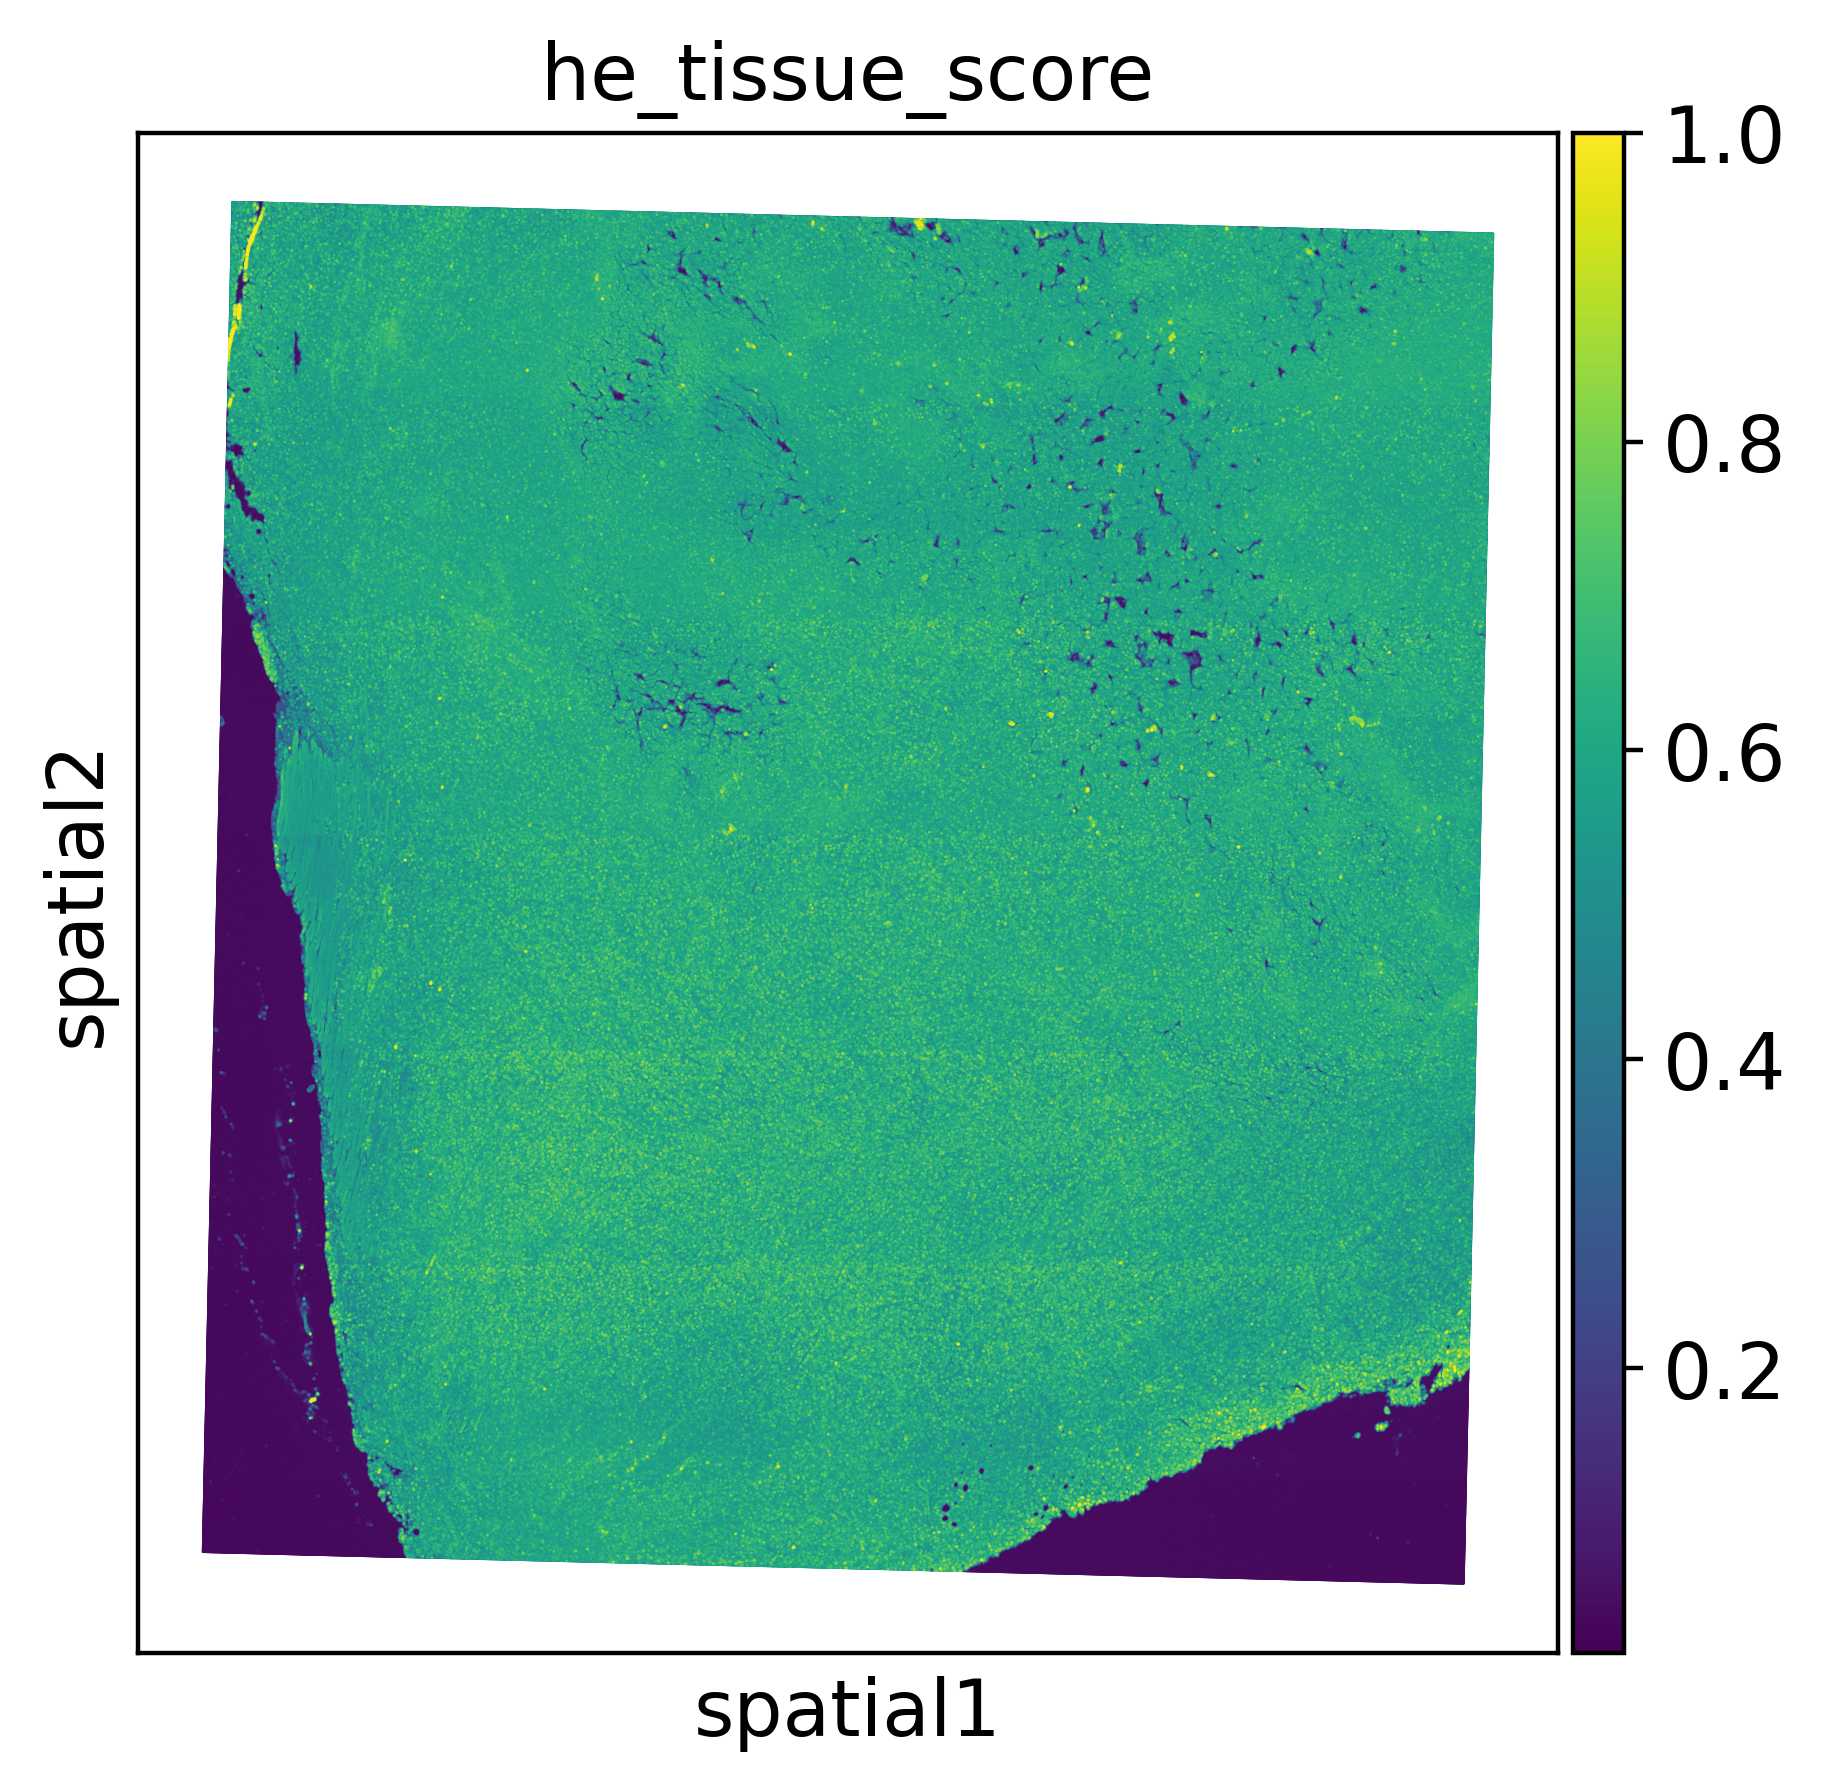

In [14]:
#examine signal distribution over transcript, image features and tissue masks
sc.set_figure_params(dpi = 200, dpi_save = 450, figsize = (5, 5))
#calculate qc metircs for transcript level plots
#
sc.pl.embedding(vdata.tables['square_002um']
                , basis="spatial", size=0.5
                , color = 'he_tissue_score'
                )
del vdata

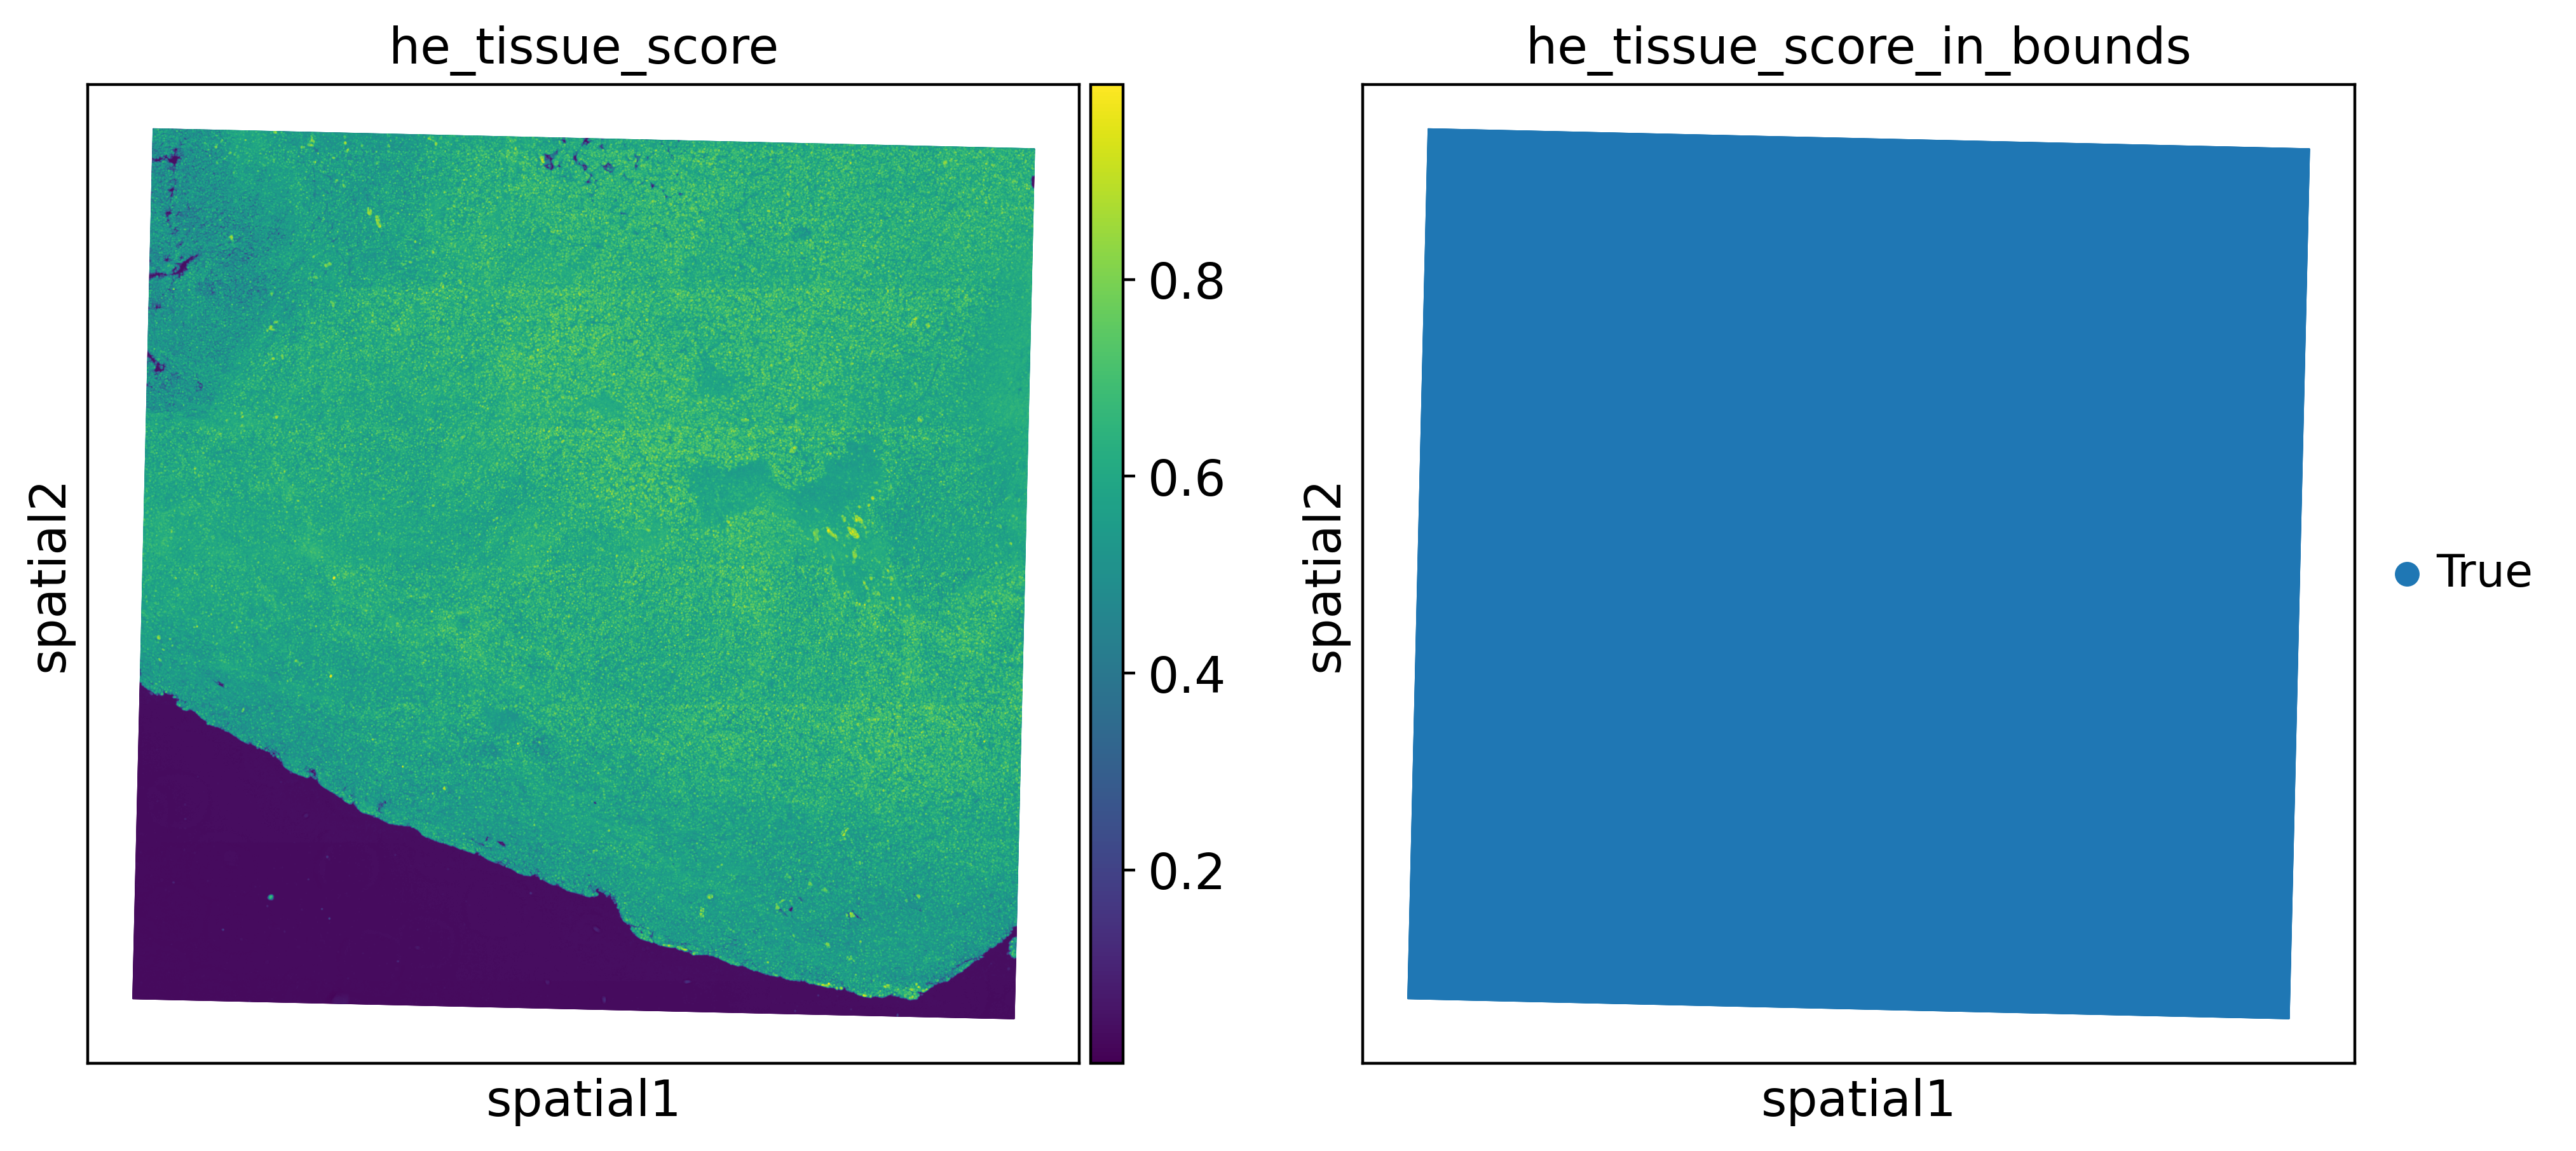

In [16]:
#examine signal distribution over transcript, image features and tissue masks
sc.set_figure_params(dpi = 200, dpi_save = 450, figsize = (5, 5))
#
sc.pl.embedding(visiumhd_ls['sample_Ada-7'].tables['square_002um']
                , basis="spatial", size=0.5, ncols = 2
                , color = ['he_tissue_score','he_tissue_score_in_bounds']
                )

In [17]:
#update the .zarr file on disk for all the slots that were changed 
for key, s in visiumhd_ls.items():
    report_info = "Now we are working on spatialdata: " + key
    print(report_info)
    persist_changes(
        s,
        update_elements=["square_002um"],
        #new_elements=["annotations_clean", "qc.annotation", 'tumor_stromal.annotation'],
        update_transformations=True,
        consolidate_metadata=True,
    )

Now we are working on spatialdata: sample_Ada-7
[store] /stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/zarr_files/Ada-7.zarr

[persist plan]
  full data rewrites: ['square_002um']
  transformation-only: []
  new elements: []

[data rewrite] tables/square_002um
[backup] temporary element: backup_square_002um_be3237c3
[backup] written: backup_square_002um_be3237c3
[data rewrite] old on-disk element removed: square_002um
[data rewrite] updated element written: square_002um

[metadata] writing SpatialData metadata
[metadata] consolidating Zarr metadata

[done] selected changes persisted successfully.
Now we are working on spatialdata: sample_Ada-6
[store] /stash/data/nonclin/TBIO-8110_VisiumHD-Adagrasib-mouseTumor/zarr_files/Ada-6.zarr

[persist plan]
  full data rewrites: ['square_002um']
  transformation-only: []
  new elements: []

[data rewrite] tables/square_002um
[backup] temporary element: backup_square_002um_3f8f3022
[backup] written: backup_square_002um_3f8f3022
[data

In [18]:
#print environment and packages used
%watermark -d -i -m -iv -v --gpu

Python implementation: CPython
Python version       : 3.10.6
IPython version      : 8.16.1

Compiler    : GCC 7.5.0
OS          : Linux
Release     : 6.1.158-178.288.amzn2023.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 96
Architecture: 64bit

matplotlib      : 3.8.4
tqdm            : 4.66.1
spatialdata     : 0.3.0
json            : 2.0.9
scanpy          : 1.10.0
spatialdata_plot: 0.2.9
anndata         : 0.11.4
pandas          : 2.2.3
scipy           : 1.15.3
watermark       : 2.5.0
squidpy         : 1.6.5
re              : 2.2.1
cv2             : 4.8.1
shapely         : 2.1.2
geopandas       : 1.0.1
sys             : 3.10.6 (main, Oct 11 2023, 09:47:13) [GCC 7.5.0]
numpy           : 1.24.4
spatialdata_io  : 0.3.0

GPU Info: NVIDIA drivers do not appear to be installed on this machine.

